In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# RF, XGBOOST ve LGBM modelleri için gerekli kütüphaneler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# LSTM ve CNN modeli kurmak için gerekli kütüphaneler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
data_gunluk = pd.read_excel("Elektrik_uretim_tuketim_gunluk.xlsx")

data_gunluk = data_gunluk.set_index("DateTime")
data_gunluk.index = pd.to_datetime(data_gunluk.index)

# Makine Öğrenimi Veri Hazırlığı (Günlük veri kullanıldı)

In [3]:
# Veriyi eğitim ve test verisi olarak ayırma
# Zaman serilerinde gözlemler arasında zamansal bağımlılık bulunduğundan, eğitim ve test verileri rastgele değil, zaman sırası korunacak şekilde ayrılmalıdır.
# Zaman serisi verisi 01.01.2019–19.03.2025 dönemini kapsamaktadır. Modelin geleceği tahmin etme performansını gerçekçi biçimde değerlendirmek amacıyla, veriler zaman sırası korunarak ayrılmış; 2019–2023 dönemi eğitim, 2024–2025 dönemi test verisi olarak kullanılmıştır.
# Rasgele ağaçlar modelinde zaman serisi verisi kullabilmek için lag, rolling ve takvimsel değişkenler eklenmesi gerekir. Eğer bunlar eklenmesse rastgele ağaçlar modeli zaman bağımlılığını bilmez, model trend yakalayamaz, Ani yükseliş ve düşüşleri göremez ve mevsimsel kırılmaları anlayamaz.
# Consumption (Tüketim) tahmin edilmek istendiği için bağımlı değişken olarak alıyoruz.

In [4]:
m_data_gunluk = data_gunluk.copy()

In [5]:
# lag (geçikme) özellikleri belirlendi
m_data_gunluk["lag_1"]  = m_data_gunluk["Consumption"].shift(1)
m_data_gunluk["lag_7"]  = m_data_gunluk["Consumption"].shift(7)
m_data_gunluk["lag_14"] = m_data_gunluk["Consumption"].shift(14)
m_data_gunluk["lag_30"] = m_data_gunluk["Consumption"].shift(30)

In [6]:
# Rollin özellikleri belirlendi.
m_data_gunluk["roll_7"]  = m_data_gunluk["Consumption"].rolling(7).mean()
m_data_gunluk["roll_14"] = m_data_gunluk["Consumption"].rolling(14).mean()
m_data_gunluk["roll_30"] = m_data_gunluk["Consumption"].rolling(30).mean()

In [7]:
m_data_gunluk["dow"]   = m_data_gunluk.index.dayofweek
m_data_gunluk["month"] = m_data_gunluk.index.month
m_data_gunluk["week"]  = m_data_gunluk.index.isocalendar().week.astype(int)

In [8]:
m_data_gunluk.isna().sum()

Consumption       0
Production        0
Nuclear           0
Wind              0
Hydroelectric     0
Oil and Gas       0
Coal              0
Solar             0
Biomass           0
lag_1             1
lag_7             7
lag_14           14
lag_30           30
roll_7            6
roll_14          13
roll_30          29
dow               0
month             0
week              0
dtype: int64

In [9]:
# zaman serisi yapısından dolayı ilk verilerde lag'dan dolayı NaN değerler oluştu. Bu NaN değer olan gözlemler çıkarıldı.
# 2019-01-01 ve 2019-01-31 arası değerlerde NaN değerler oluştuğu için bu alanı cıkardık.
m_data_gunluk = m_data_gunluk.dropna()

In [10]:
m_data_gunluk.isna().sum()

Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
lag_1            0
lag_7            0
lag_14           0
lag_30           0
roll_7           0
roll_14          0
roll_30          0
dow              0
month            0
week             0
dtype: int64

In [11]:
m_train = m_data_gunluk[m_data_gunluk.index < "2024-01-01"]
m_test  = m_data_gunluk[m_data_gunluk.index >= "2024-01-01"]

In [12]:
m_train.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,lag_1,lag_7,lag_14,lag_30,roll_7,roll_14,roll_30,dow,month,week
DateTime,,,,,,,,,,,,,,,,,,,
2019-01-31,193091,175920,33045,11716,40074,44194,44656,851,1359,190694.0,189681.0,193556.0,142984.0,187694.142857,188274.071429,187487.633333,3,1,5
2019-02-01,189721,173835,33111,12014,40785,43312,40370,2822,1388,193091.0,193859.0,192045.0,151729.0,187103.000000,188108.071429,188754.033333,4,2,5
2019-02-02,170323,169258,33443,19635,36101,41427,35291,2019,1326,189721.0,182890.0,183552.0,174098.0,185307.714286,187163.142857,188628.200000,5,2,5
2019-02-03,159004,161640,33472,10228,44073,32884,38236,1537,1183,170323.0,167374.0,170604.0,183242.0,184112.000000,186334.571429,187820.266667,6,2,5
2019-02-04,179871,166568,33042,8085,44172,40401,36767,2775,1305,159004.0,192812.0,192251.0,177114.0,182263.285714,185450.285714,187912.166667,0,2,6


In [13]:
m_test.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,lag_1,lag_7,lag_14,lag_30,roll_7,roll_14,roll_30,dow,month,week
DateTime,,,,,,,,,,,,,,,,,,,
2024-01-01,119268,147777,33517,26423,32042,33596,18325,1834,749,131397.0,122506.0,171618.0,146032.0,134116.571429,145982.214286,158376.633333,0,1,1
2024-01-02,127948,153834,33466,14780,48861,34190,19295,2492,747,119268.0,123158.0,172742.0,140639.0,134800.857143,142782.642857,157953.600000,1,1,1
2024-01-03,150169,175152,32867,34589,50395,34792,20467,687,855,127948.0,135975.0,174728.0,170475.0,136828.571429,141028.428571,157276.733333,2,1,1
2024-01-04,156396,184438,33238,37192,51195,38724,20594,1689,1280,150169.0,145886.0,170552.0,177778.0,138330.000000,140017.285714,156564.000000,3,1,1
2024-01-05,154073,178180,33320,28650,51892,39639,19617,3777,1273,156396.0,143093.0,166041.0,173552.0,139898.571429,139162.428571,155914.700000,4,1,1


In [14]:
m_x_train = m_train.drop("Consumption", axis=1)
m_y_train = m_train["Consumption"]

m_x_test  = m_test.drop("Consumption", axis=1)
m_y_test  = m_test["Consumption"]

# RASTGELE AĞAÇLAR MODELİ

In [16]:
rf = RandomForestRegressor(
    n_estimators=500,        # Ağaç sayısı
    max_depth=12,            # Aşırı öğrenmeyi önler
    min_samples_leaf=5,      # Bir yaprak düğümde bulunması gereken minimum gözlem sayısını
    min_samples_split=10,    # Bir düğümün bölünebilmesi için gerekli olan minimum örnek sayısını
    random_state=42,         # Model için rastgelelik sabiti
)

rf.fit(m_x_train, m_y_train)  # Model eğitimi

RandomForestRegressor(max_depth=12, min_samples_leaf=5, min_samples_split=10,
                      n_estimators=500, random_state=42)

In [17]:
rf_y_pred = rf.predict(m_x_test)

In [18]:
# model performansı değerlendirme
# MAE
rf_mae = mean_absolute_error(m_y_test, rf_y_pred)
# RMSE
rf_rmse = np.sqrt(mean_squared_error(m_y_test, rf_y_pred))
# MAPE (%)
rf_mape = np.mean(np.abs((m_y_test - rf_y_pred) / m_y_test)) * 100
# MASE
# Naive forecast hatası (eğitim seti)
rf_naive_error = np.mean(np.abs(m_y_train.diff().dropna()))
rf_mase = rf_mae / rf_naive_error

In [19]:
rf_performance = pd.DataFrame({
    "Model": ["Random Forest"],
    "RF_MAE": [rf_mae],
    "RF_RMSE": [rf_rmse],
    "RF_MAPE (%)": [rf_mape],
    "RF_MASE": [rf_mase]
})

print(rf_performance)

           Model       RF_MAE       RF_RMSE  RF_MAPE (%)   RF_MASE
0  Random Forest  8663.857645  16025.701721          inf  0.991063


In [20]:
# Kritik eşikler

# MASE < 1 → başarılı model
# MAPE < %10 → çok iyi
# MAPE %10–20 → iyi
# RMSE ≫ MAE → uç değer problemi olabilir

In [21]:
# Özellik önem düzeyleri
rf_feature_importance = pd.Series(
    rf.feature_importances_,
    index=m_x_train.columns
).sort_values(ascending=False)

print(rf_feature_importance.head(10))

lag_7          0.649034
roll_7         0.136808
lag_1          0.110700
dow            0.043050
lag_14         0.020583
Production     0.006022
week           0.004210
Solar          0.003908
Coal           0.003828
Oil and Gas    0.003385
dtype: float64


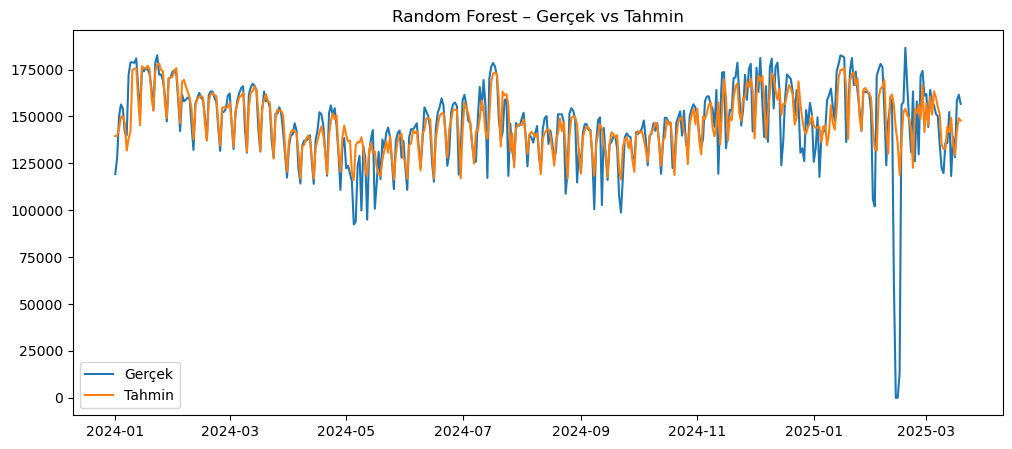

In [22]:
# Gerçek değerler ile tahmin değerlerini görselleştirme
plt.figure(figsize=(12,5))
plt.plot(m_y_test.index, m_y_test, label="Gerçek")
plt.plot(m_y_test.index, rf_y_pred, label="Tahmin")
plt.legend()
plt.title("Random Forest – Gerçek vs Tahmin")
plt.show()

# XGBOOST MODELİ

In [23]:
xgb = XGBRegressor(
    n_estimators=500,    # Modelde oluşturulacak zayıf ağaç sayısını
    learning_rate=0.05,  # Her bir ağacın modele yaptığı katkının öğrenme hızı
    max_depth=6,         # Her bir ağacın maksimum derinliği
    subsample=0.8,       # Her bir ağacın eğitilirken kullanılan gözlem oranı
    colsample_bytree=0.8,  # Her bir ağacın oluşturulmasında kullanılan özellik oranını
    min_child_weight=5,  # Bir yaprak düğümde bulunması gereken minimum örnek ağırlığı
    objective="reg:squarederror",  # Modelin optimizasyon (kayıp) fonksiyonu
    random_state=42,  # Model için rastgelelik sabiti
    n_jobs=-1    # Modelin tüm işlemci çekirdeklerini kullanmasını sağlar.
)

xgb.fit(m_x_train, m_y_train) # Model eğitimi

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [24]:
y_pred_xgb = xgb.predict(m_x_test)

In [25]:
# model performansı değerlendirme
# MAE
mae_xgb = mean_absolute_error(m_y_test, y_pred_xgb)

# RMSE
rmse_xgb = np.sqrt(mean_squared_error(m_y_test, y_pred_xgb))

# MAPE (%)
mape_xgb = np.mean(np.abs((m_y_test - y_pred_xgb) / m_y_test)) * 100

# MASE (naive eğitim setinden)
xgb_naive_error = np.mean(np.abs(m_y_train.diff().dropna()))
mase_xgb = mae_xgb / xgb_naive_error

In [26]:
xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "MAE": [mae_xgb],
    "RMSE": [rmse_xgb],
    "MAPE (%)": [mape_xgb],
    "MASE": [mase_xgb]
})

print(xgb_results)

     Model         MAE          RMSE  MAPE (%)      MASE
0  XGBoost  7980.11175  14672.228312       inf  0.912849


In [27]:
# Özellik önem düzeyleri
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=m_x_train.columns
).sort_values(ascending=False)

print(xgb_importance.head(10))

lag_7         0.382803
roll_7        0.197835
dow           0.147684
lag_1         0.145725
lag_14        0.026134
week          0.014035
Production    0.010407
roll_14       0.009976
Coal          0.009091
month         0.008748
dtype: float32


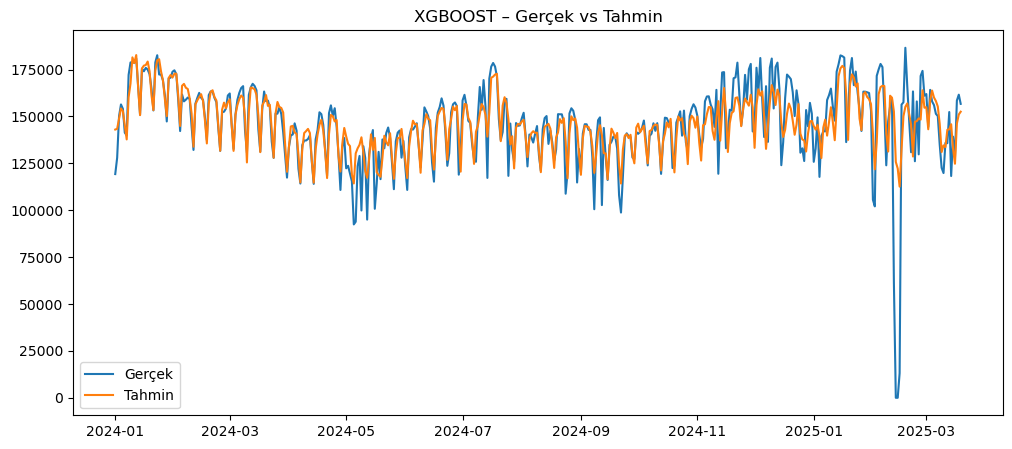

In [28]:
# Gerçek değerler ile tahmin değerlerini görselleştirme
plt.figure(figsize=(12,5))
plt.plot(m_y_test.index, m_y_test, label="Gerçek")
plt.plot(m_y_test.index, y_pred_xgb, label="Tahmin")
plt.legend()
plt.title("XGBOOST – Gerçek vs Tahmin")
plt.show()

# LİGHT GBM MODELİ

In [29]:
lgbm = LGBMRegressor(
    n_estimators=1000,  # Modelde oluşturulacak zayıf ağaç sayısını
    learning_rate=0.05, # Her bir ağacın modele yaptığı katkının öğrenme hızı
    max_depth=-1,          # LightGBM kendi karar versin. Her bir ağacın maksimum derinliği
    num_leaves=31,         # kritik parametre Model karmaşıklığını dengeler
    subsample=0.8,      # Her bir ağacın eğitilirken kullanılan gözlem oranı
    colsample_bytree=0.8,  # Her bir ağacın oluşturulmasında kullanılan özellik oranını
    min_child_samples=20,  # Bir yaprak düğümde bulunması gereken minimum örnek ağırlığı
    random_state=42,    # Model için rastgelelik sabiti
    n_jobs=-1         # Modelin tüm işlemci çekirdeklerini kullanmasını sağlar.
)

lgbm.fit(m_x_train, m_y_train) # Model eğitimi

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3899
[LightGBM] [Info] Number of data points in the train set: 1796, number of used features: 18
[LightGBM] [Info] Start training from score 157723.883073


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
              n_jobs=-1, random_state=42, subsample=0.8)

In [30]:
y_pred_lgbm = lgbm.predict(m_x_test)

In [31]:
# MAE
mae_lgbm = mean_absolute_error(m_y_test, y_pred_lgbm)

# RMSE
rmse_lgbm = np.sqrt(mean_squared_error(m_y_test, y_pred_lgbm))

# MAPE (%)
mape_lgbm = np.mean(np.abs((m_y_test - y_pred_lgbm) / m_y_test)) * 100

# MASE (naive: t-1)
lgbm_naive_error = np.mean(np.abs(m_y_train.diff().dropna()))
mase_lgbm = mae_lgbm / lgbm_naive_error

In [32]:
results_lgbm = pd.DataFrame({
    "Model": ["LightGBM"],
    "MAE": [mae_lgbm],
    "RMSE": [rmse_lgbm],
    "MAPE (%)": [mape_lgbm],
    "MASE": [mase_lgbm]
})

print(results_lgbm)

      Model          MAE          RMSE  MAPE (%)      MASE
0  LightGBM  8186.368397  14938.972219       inf  0.936443


In [33]:
# Özellik önem düzeyleri
importance_lgbm = pd.Series(
    lgbm.feature_importances_,
    index=m_x_train.columns
).sort_values(ascending=False)

print(importance_lgbm.head(10))

lag_1            2401
Biomass          2313
Nuclear          2039
Wind             2032
Hydroelectric    1945
Oil and Gas      1933
lag_7            1891
lag_30           1828
Solar            1814
Coal             1739
dtype: int32


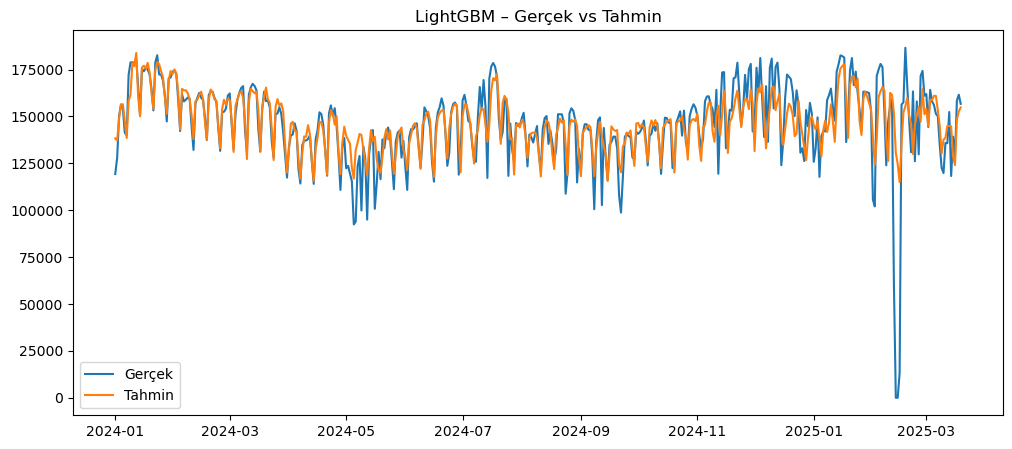

In [35]:
# Gerçek değerler ile tahmin değerlerini görselleştirme
plt.figure(figsize=(12,5))
plt.plot(m_y_test.index, m_y_test, label="Gerçek")
plt.plot(m_y_test.index, y_pred_lgbm, label="Tahmin")
plt.legend()
plt.title("LightGBM – Gerçek vs Tahmin")
plt.show()

# LSTM ve CNN modeli için veri hazırlama

In [36]:
# LSTM ve CNN modellerinde eğitim ve test veri setleri farklı ayrılıyor. Zamana bağımlılığı model kendisi öğreniyor.
d_data_gunluk = data_gunluk.copy()
d_train = d_data_gunluk[d_data_gunluk.index < "2024-01-01"]
d_test  = d_data_gunluk[d_data_gunluk.index >= "2024-01-01"]

In [37]:
features = ["Production", "Nuclear", "Wind", "Hydroelectric", "Oil and Gas", "Coal", "Solar", "Biomass"]

In [38]:
d_x_train = d_train.drop("Consumption", axis=1)
d_y_train = d_train[["Consumption"]]

d_x_test  = d_test.drop("Consumption", axis=1)
d_y_test  = d_test[["Consumption"]]

In [39]:
# Sinir ağları modeli olduğu için ölçekleme yapmak zorundayız. Lakin bunu sadece eğitim verisi için yapıyoruz.
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

d_x_train_scaled = x_scaler.fit_transform(d_x_train)
d_x_test_scaled  = x_scaler.transform(d_x_test)

d_y_train_scaled = y_scaler.fit_transform(d_y_train)
d_y_test_scaled  = y_scaler.transform(d_y_test)

In [40]:
# 30 günlük bir pencere oluşturuldu.
def create_lstm_sequences(data, window_size=30):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])  # 30 gün × feature
        y.append(data[i, 0])                # Consumption (t)
    return np.array(X), np.array(y)

WINDOW = 30

X_train_l, y_train_l = create_lstm_sequences(d_x_train_scaled, WINDOW)
X_test_l,  y_test_l  = create_lstm_sequences(d_x_test_scaled, WINDOW)

In [41]:
print(X_train_l.shape)
print(y_train_l.shape)

(1796, 30, 8)
(1796,)


# LSTM modeli

In [42]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_l.shape[1], X_train_l.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model.compile(
    optimizer="adam",
    loss="mse"
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)
history = model.fit(
    X_train_l, y_train_l,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - loss: 0.0864 - val_loss: 0.0112
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0196 - val_loss: 0.0097
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0164 - val_loss: 0.0100
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0158 - val_loss: 0.0118
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0145 - val_loss: 0.0098
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0145 - val_loss: 0.0098
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0151 - val_loss: 0.0102
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0146 - val_loss: 0.0099
Epoch 9/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0142 - val_loss: 0.0100
Epoch 10/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0140 - val_loss: 0.0097
Epoch 11/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0148 - val_loss: 0.0097
Epoch 12/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/ste

In [43]:
y_pred_scaled = model.predict(X_test_l)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


In [44]:
y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled)
y_test_real = y_scaler.inverse_transform(y_test_l.reshape(-1, 1))

In [45]:
lstm_mae  = mean_absolute_error(y_test_real, y_pred_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_lstm))
lstm_mape = np.mean(np.abs((y_test_real - y_pred_lstm) / y_test_real)) * 100
# Naive forecast (t-1)
lstm_naive_forecast = y_test_real[:-1]
lstm_actual = y_test_real[1:]
lstm_mase = lstm_mae / np.mean(np.abs(lstm_actual - lstm_naive_forecast))

In [46]:
# Model performans başarısı
results_lstm = pd.DataFrame({
    "Model": ["LSTM"],
    "MAE": [lstm_mae],
    "RMSE": [lstm_rmse],
    "MAPE (%)": [lstm_mape],
    "MASE": [lstm_mase]
})

print(results_lstm)

  Model           MAE          RMSE   MAPE (%)      MASE
0  LSTM  11742.631774  16892.280236  10.792494  1.040265


In [47]:
y_test_reala = d_y_test.index[WINDOW:]

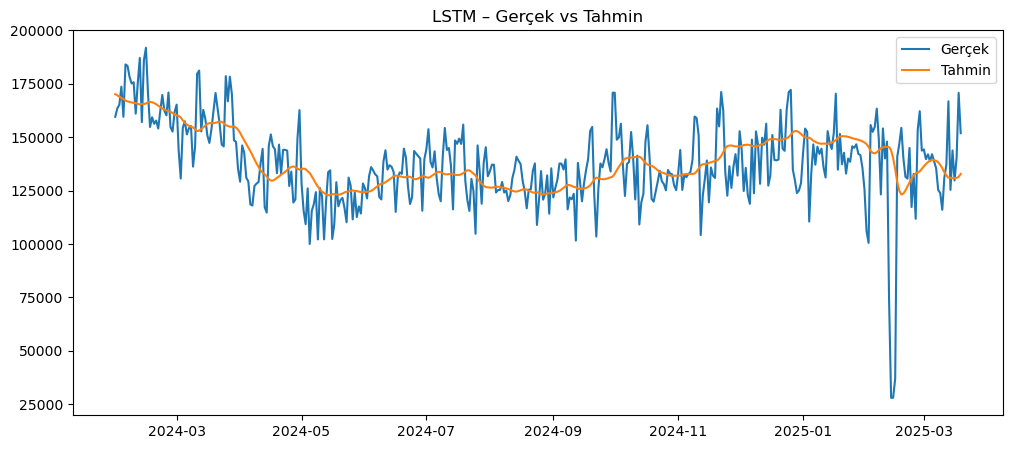

In [48]:
# Gerçek değerler ile tahmin değerlerini görselleştirme
plt.figure(figsize=(12,5))
plt.plot(y_test_reala, y_test_real, label="Gerçek")
plt.plot(y_test_reala, y_pred_lstm, label="Tahmin")
plt.legend()
plt.title("LSTM – Gerçek vs Tahmin")
plt.show()

# CNN MODELİ

In [49]:
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation="relu",
           input_shape=(X_train_l.shape[1], X_train_l.shape[2])),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=3, activation="relu"),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
cnn_model.compile(
    optimizer="adam",
    loss="mse"
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)
cnn_history = cnn_model.fit(
    X_train_l, y_train_l,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0349 - val_loss: 0.0185
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0191 - val_loss: 0.0123
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0154 - val_loss: 0.0098
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0144 - val_loss: 0.0098
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0123 - val_loss: 0.0126
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0129 - val_loss: 0.0100
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0119 - val_loss: 0.0128
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0113 - val_loss: 0.0108
Epoch 9/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0106 - val_loss: 0.0125
Epoch 10/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0104 - val_loss: 0.0101
Epoch 11/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0104 - val_loss: 0.0131
Epoch 12/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

In [50]:
# Tahmin
y_pred_cnn_scaled = cnn_model.predict(X_test_l)

y_pred_cnn = y_scaler.inverse_transform(y_pred_cnn_scaled)
y_test_real_cnn = y_scaler.inverse_transform(y_test_l.reshape(-1,1))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [51]:
mae_cnn = mean_absolute_error(y_test_real_cnn, y_pred_cnn)
rmse_cnn = np.sqrt(mean_squared_error(y_test_real_cnn, y_pred_cnn))
mape_cnn = np.mean(np.abs((y_test_real_cnn - y_pred_cnn) / y_test_real_cnn)) * 100

# Naive forecast (t-1)
cnn_naive = y_test_real_cnn[:-1]
mase_cnn = mae_cnn / np.mean(np.abs(y_test_real_cnn[1:] - cnn_naive))

In [52]:
# Model performans başarısı
results_cnn = pd.DataFrame({
    "Model": ["CNN"],
    "MAE": [mae_cnn],
    "RMSE": [rmse_cnn],
    "MAPE (%)": [mape_cnn],
    "MASE": [mase_cnn]
})

print(results_cnn)

  Model           MAE          RMSE   MAPE (%)      MASE
0   CNN  12245.266442  17984.609421  11.497259  1.084792


In [53]:
y_test_realc = d_y_test.index[WINDOW:]

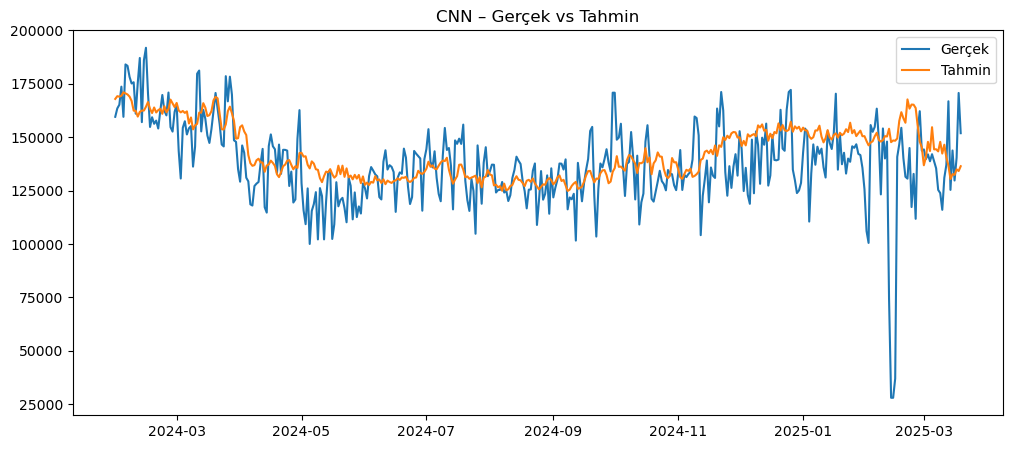

In [54]:
# Gerçek değerler ile tahmin değerlerini görselleştirme
plt.figure(figsize=(12,5))
plt.plot(y_test_realc, y_test_real_cnn, label="Gerçek")
plt.plot(y_test_realc, y_pred_cnn, label="Tahmin")
plt.legend()
plt.title("CNN – Gerçek vs Tahmin")
plt.show()

# Tüm Modellerin Karşılaştırılması

In [55]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "LSTM", "CNN"],
    "MAE":  [rf_mae, mae_xgb, mae_lgbm, lstm_mae, mae_cnn],
    "RMSE": [rf_rmse, rmse_xgb, rmse_lgbm, lstm_rmse, rmse_cnn],
    "MAPE (%)": [rf_mape, mape_xgb, mape_lgbm, lstm_mape, mape_cnn],
    "MASE": [rf_mase, mase_xgb, mase_lgbm, lstm_mase, mase_cnn]
})

results

,Model,MAE,RMSE,MAPE (%),MASE
0,Random Forest,8663.857645,16025.701721,inf,0.991063
1,XGBoost,7980.111750,14672.228312,inf,0.912849
2,LightGBM,8186.368397,14938.972219,inf,0.936443
3,LSTM,11742.631774,16892.280236,10.792494,1.040265
4,CNN,12245.266442,17984.609421,11.497259,1.084792


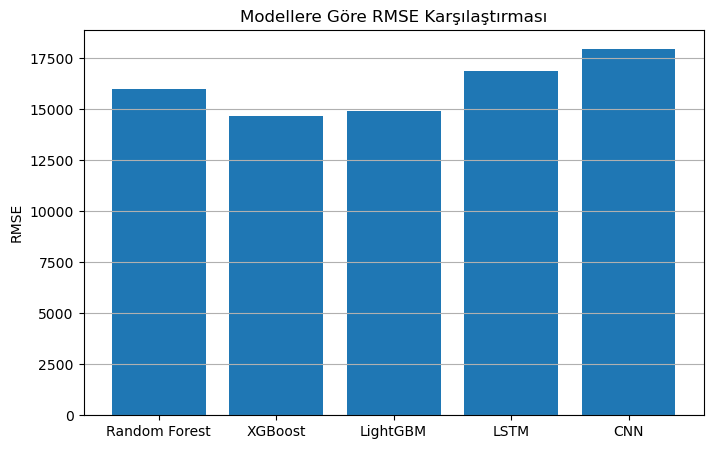

In [56]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["RMSE"])
plt.title("Modellere Göre RMSE Karşılaştırması")
plt.ylabel("RMSE")
plt.grid(axis="y")
plt.show()